# Assignment — Logistic Regression on `penguins.csv`

**Question:** given a penguin's measurements, is it male or female?

Target: `sex` &nbsp;·&nbsp; File: `penguins.csv`

Use only the numeric columns: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`,
`body_mass_g`.

**Keep this notebook.** Next class we will come back to the model you build here and
measure it properly.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../Data/penguins.csv')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---
## 1. Look at the data

> **Flow:** Shape, columns, missing values.

Run `.info()`. Which columns have missing values, and how many?

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

How many male and how many female? Use `sns.countplot`.

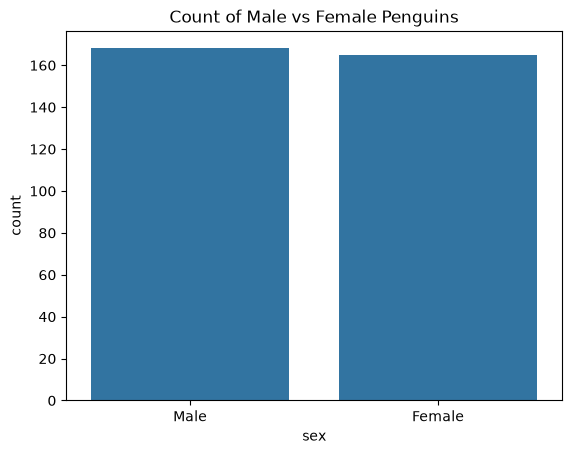

sex
Male      168
Female    165
Name: count, dtype: int64


In [4]:
sns.countplot(data=df, x='sex')
plt.title('Count of Male vs Female Penguins')
plt.show()

print(df['sex'].value_counts())

*Counts:* Male: 168, Female: 165 &nbsp;&nbsp; *Are the two classes roughly equal, or is one much bigger?*

#### ANS : The two classes are roughly equal (168 Male and 165 Female).

Now compare the two groups on one measurement. Use `sns.barplot` with `x='sex'` and
`y='body_mass_g'`.

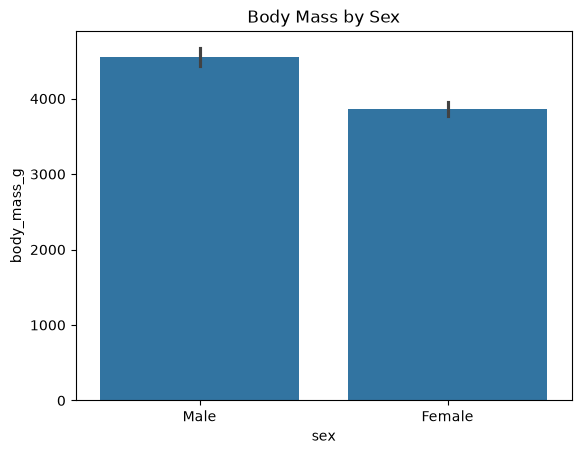

In [4]:
sns.barplot(data=df, x='sex', y='body_mass_g')
plt.title('Body Mass by Sex')
plt.show()

**Q.** Looking at that plot, does `body_mass_g` look useful for telling males and females
apart? One line.

#### ANS : Yes, male penguins have a noticeably higher average body mass than female penguins, making it a useful feature for telling them apart.

---
## 2. Clean

> **Flow:** The target cannot be guessed. Rows missing it have to go.

`sex` is what we are trying to predict, so we cannot fill it in. Keep the four numeric
columns plus `sex`, then `dropna()`.

In [5]:
# Keep the 4 numeric columns + sex, then drop rows with missing values
df = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']].dropna()
print("Rows left:", df.shape[0])
df.head()

Rows left: 333

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,Male
1,39.5,17.4,186.0,3800.0,Female
2,40.3,18.0,195.0,3250.0,Female
4,36.7,19.3,193.0,3450.0,Female
5,39.3,20.6,190.0,3650.0,Male


*How many rows are left?*

#### ANS : 333 rows are left (11 rows with missing values were dropped).

The target is text — `Male` and `Female`. Map it to numbers:
`{'Female': 0, 'Male': 1}`.

In [6]:
df['sex'] = df['sex'].map({'Female': 0, 'Male': 1})
df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,1
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
4,36.7,19.3,193.0,3450.0,0
5,39.3,20.6,190.0,3650.0,1


---
## 3. Features and target

In [7]:
# Features and target
x = df.drop(columns=['sex'])  # independent features
y = df['sex']                 # dependent target (0 = Female, 1 = Male)

---
## 4. Split

> **Flow:** `test_size=0.2`, `random_state=42`, `stratify=y`.

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (266, 4)
x_test shape: (67, 4)

**Q.** Why do we use `stratify=y` here? One line.

#### ANS : `stratify=y` ensures that both training and testing sets maintain the same proportion of male and female classes as the original dataset.

---
## 5. Train the model

> **Flow:** Two lines, same as always.

Train `LogisticRegression(max_iter=1000)` and predict on the test set.

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(y_pred)

[1 0 1 0 0 1 1 1 1 1 0 1 0 1 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 1 1 0 0 1 1 0
 1 1 0 0 1 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 1 1 0 1 1 0 0 0 1]

**Q.** What does `max_iter=1000` do? One line.

#### ANS : `max_iter=1000` sets the maximum number of iterations allowed for the solver to converge to the optimal parameters.

---
## 6. Accuracy

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8656716417910447